# Librosa Features EDA

**Goal:** Determine whether librosa-extracted features (MFCCs, chroma, spectral contrast, and scalar features) provide useful signal for the AT-DJ playlist system.

**Decision we're making:** Should we include these features in the scoring pipeline, or skip them in favor of essentia-only features?

**Note on data:**
Due to time efficiency, we have only extracted librosa features for milonga and vals. Thus, we will only be comparing essentia and librosa features for these two styles, but insights should apply for tango.

- `librosa_milonga.csv` — 37 milonga tracks
- `librosa_vals.csv` — 41 vals tracks  
- `essentia_milonga.csv` — 37 milonga tracks (same files, essentia features)
- `essentia_vals.csv` — 41 vals tracks (same files, essentia features)
- `catalog.csv` — full ~1024 track catalog with metadata

**Key questions:**
1. Do the scalar features (energy, rhythmic drive, harmonic ratio, tempo) differ meaningfully across styles?
2. Do MFCCs cluster by orchestra (which would make them useful for combo scoring)?
3. Does chroma provide signal beyond what style+decade already tells us?
4. Are the features stable/reliable (low noise) given old mono recordings?
5. Do any features correlate in ways useful for the user prompt → feature translation?
6. Are librosa features redundant given essentia features we already have?
7. Do essentia mood/scale features actually separate orchestras within a style?

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats
import umap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Libraries loaded.')

Libraries loaded.


## 1. Load & Merge Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# --- Load librosa CSVs ---
lm = pd.read_csv('drive/MyDrive/GenAI/proj/librosa_milonga.csv')
lv = pd.read_csv('drive/MyDrive/GenAI/proj/librosa_vals.csv')
cat = pd.read_csv('drive/MyDrive/GenAI/proj/catalog.csv')

# --- Load essentia CSVs ---
em = pd.read_csv('drive/MyDrive/GenAI/proj/essentia_milonga.csv')
ev = pd.read_csv('drive/MyDrive/GenAI/proj/essentia_vals.csv')

lm['style_from_file'] = 'milonga'
lv['style_from_file'] = 'vals'
em['style_from_file'] = 'milonga'
ev['style_from_file'] = 'vals'

librosa = pd.concat([lm, lv], ignore_index=True)
essentia = pd.concat([em, ev], ignore_index=True)

# Merge librosa with catalog metadata
merged = librosa.merge(cat[['filename', 'orchestra', 'singer', 'decade', 'style', 'year']],
                       on='filename', how='left')
merged['style'] = merged['style'].fillna(merged['style_from_file'])

# Merge essentia with catalog metadata
ess_merged = essentia.merge(cat[['filename', 'orchestra', 'singer', 'decade', 'style', 'year']],
                            on='filename', how='left')
ess_merged['style'] = ess_merged['style'].fillna(ess_merged['style_from_file'])

# Combined dataframe: both librosa + essentia features on same tracks
both = librosa.merge(essentia, on=['filename', 'style_from_file'], how='inner', suffixes=('_lib', '_ess'))
both = both.merge(cat[['filename', 'orchestra', 'singer', 'decade']], on='filename', how='left')

print(f'Librosa tracks: {len(librosa)} | Essentia tracks: {len(essentia)} | Combined: {len(both)}')
print(f'Catalog merge — orchestra matched: {merged["orchestra"].notna().sum()} / {len(merged)}')

Librosa tracks: 78 | Essentia tracks: 78 | Combined: 78
Catalog merge — orchestra matched: 78 / 78


In [5]:
# --- Define feature groups ---
MFCC_COLS     = [c for c in merged.columns if c.startswith('mfcc_') and 'delta' not in c]
DELTA_COLS    = [c for c in merged.columns if c.startswith('delta_mfcc_')]
CHROMA_COLS   = [c for c in merged.columns if c.startswith('chroma_')]
SPECTRAL_COLS = [c for c in merged.columns if c.startswith('spectral_contrast_')]
SCALAR_COLS   = ['rms_mean', 'rms_std', 'onset_strength_mean', 'onset_strength_std',
                 'tempogram_global_mean', 'tempogram_global_std', 'tempogram_max_bin_strength',
                 'harmonic_energy', 'percussive_energy', 'harmonic_to_percussive_ratio',
                 'harmonic_energy_ratio', 'percussive_energy_ratio']

ESSENTIA_MOOD = ['mood_happy', 'mood_sad', 'mood_relaxed', 'mood_aggressive',
                 'mood_party', 'mood_acoustic']
ESSENTIA_CORE = ['bpm', 'onset_rate', 'danceability', 'average_loudness',
                 'dynamic_complexity', 'key_strength', 'chords_changes_rate', 'dissonance_mean']

READABLE = {
    'rms_mean': 'Energy Level',
    'onset_strength_mean': 'Rhythmic Drive',
    'harmonic_energy_ratio': 'Harmonic Ratio',
    'percussive_energy_ratio': 'Percussive Ratio',
    'harmonic_to_percussive_ratio': 'H/P Ratio',
    'tempogram_max_bin_strength': 'Tempo Stability',
    'tempogram_global_mean': 'Tempo (global mean)',
}

print(f'MFCC cols: {len(MFCC_COLS)}, Chroma: {len(CHROMA_COLS)}, Spectral: {len(SPECTRAL_COLS)}, Scalar: {len(SCALAR_COLS)}')
print(f'Essentia mood cols: {len(ESSENTIA_MOOD)}, core: {len(ESSENTIA_CORE)}')

MFCC cols: 26, Chroma: 24, Spectral: 14, Scalar: 12
Essentia mood cols: 6, core: 8


## 2. Basic Data Quality Check

In [8]:
print('Missing values per feature group:')
print('  Scalar:', merged[SCALAR_COLS].isnull().sum().sum())
print('  MFCC:  ', merged[MFCC_COLS].isnull().sum().sum())
print('  Chroma:', merged[CHROMA_COLS].isnull().sum().sum())
print('  Spectral:', merged[SPECTRAL_COLS].isnull().sum().sum())
print('  Essentia mood:', ess_merged[ESSENTIA_MOOD].isnull().sum().sum())
print('  Essentia core:', ess_merged[ESSENTIA_CORE].isnull().sum().sum())

delta_means = merged[[c for c in DELTA_COLS if 'mean' in c]].abs().mean()
if (delta_means < 1e-6).all():
    print('\n WARNING: Delta MFCCs are all near-zero.')
    USE_DELTA = False
else:
    USE_DELTA = True
    print('\n Delta MFCCs look valid.')

Missing values per feature group:
  Scalar: 0
  MFCC:   0
  Chroma: 0
  Spectral: 0
  Essentia mood: 0
  Essentia core: 0

 Delta MFCCs look valid.


In [9]:
# Coefficient of variation — how much spread does each feature have?
cv_lib = (merged[SCALAR_COLS].std() / merged[SCALAR_COLS].mean().abs()).sort_values(ascending=False)
cv_ess = (ess_merged[ESSENTIA_MOOD + ESSENTIA_CORE].std() /
          ess_merged[ESSENTIA_MOOD + ESSENTIA_CORE].mean().abs()).sort_values(ascending=False)

print('Librosa scalar CV (higher = more spread = potentially more useful):')
for col, val in cv_lib.items():
    bar = '█' * int(val * 20)
    print(f'  {col:35s}  {val:.3f}  {bar}')

print('\nEssentia feature CV:')
for col, val in cv_ess.items():
    bar = '█' * int(val * 20)
    print(f'  {col:35s}  {val:.3f}  {bar}')

Librosa scalar CV (higher = more spread = potentially more useful):
  percussive_energy                    0.415  ████████
  harmonic_to_percussive_ratio         0.402  ████████
  harmonic_energy                      0.355  ███████
  percussive_energy_ratio              0.296  █████
  rms_mean                             0.183  ███
  rms_std                              0.178  ███
  onset_strength_std                   0.171  ███
  onset_strength_mean                  0.094  █
  tempogram_global_mean                0.078  █
  tempogram_global_std                 0.066  █
  harmonic_energy_ratio                0.038  
  tempogram_max_bin_strength           0.006  

Essentia feature CV:
  mood_party                           0.788  ███████████████
  mood_aggressive                      0.619  ████████████
  mood_happy                           0.409  ████████
  mood_sad                             0.313  ██████
  average_loudness                     0.282  █████
  chords_changes_rate    

## 3. Scalar Features — Style Separation (Librosa)

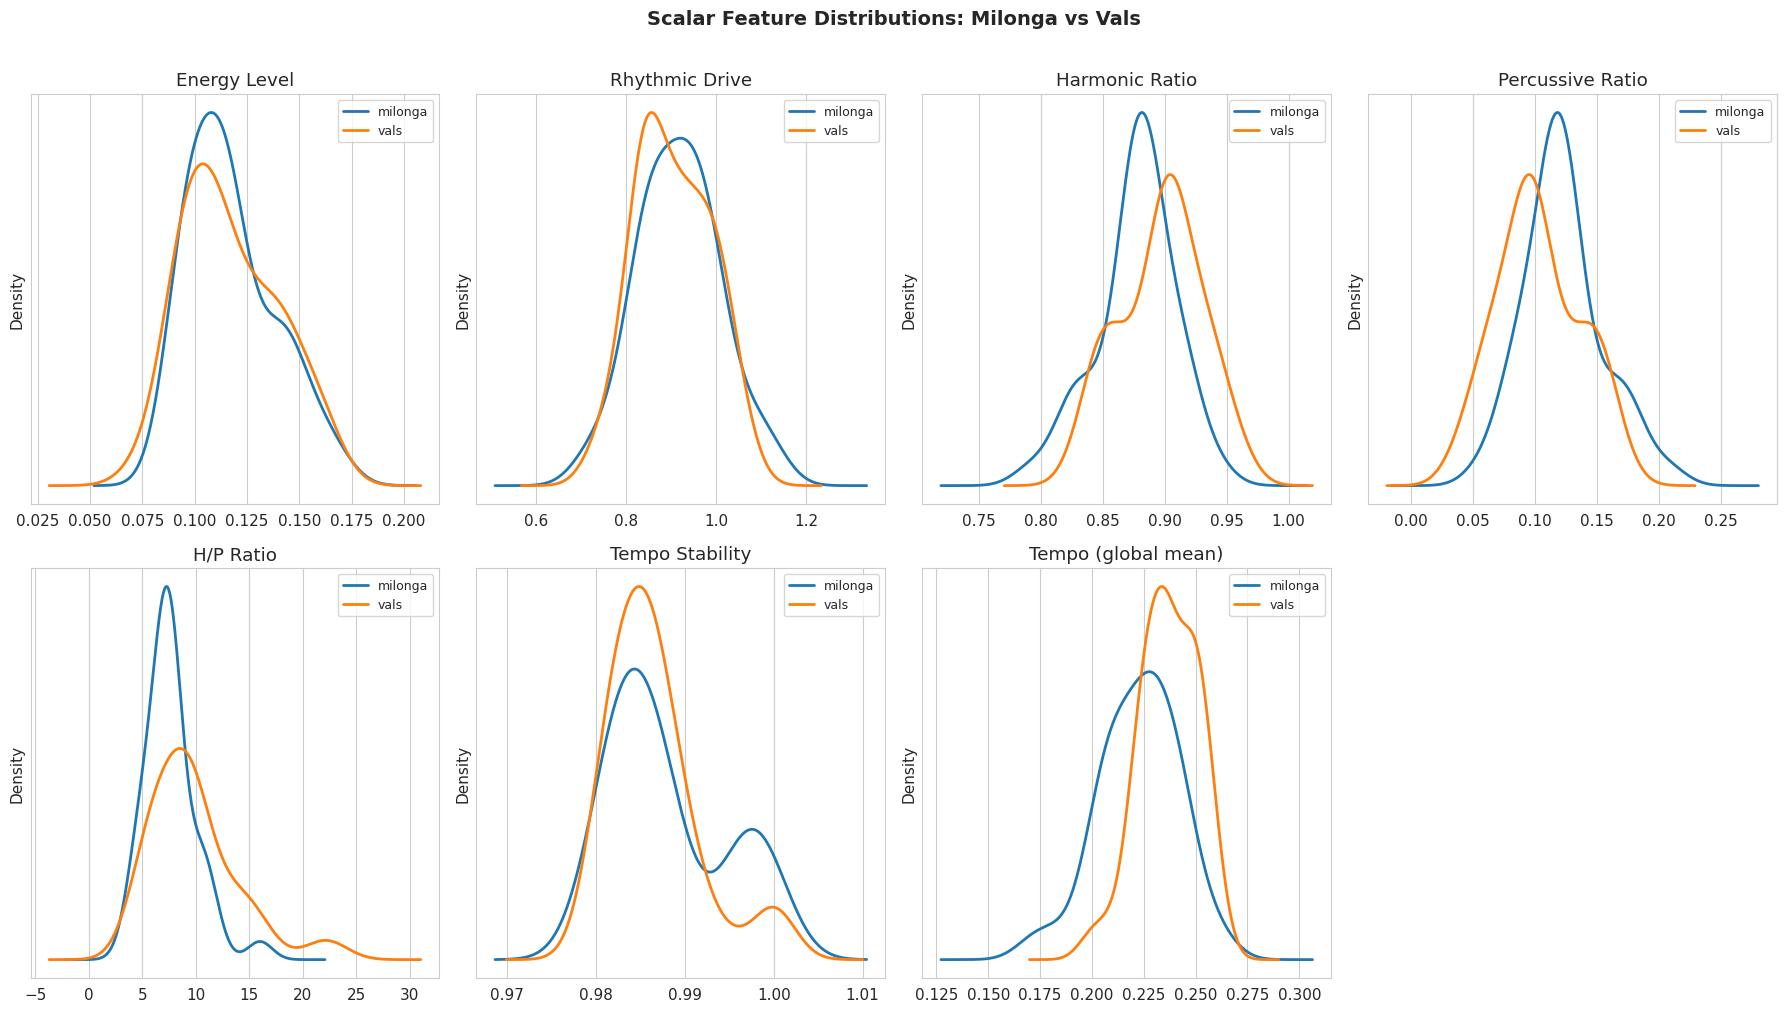

Feature                               Milonga mean    Vals mean    p-value   Separates?
------------------------------------------------------------------------------------------
Energy Level                                0.1175       0.1170     0.9211           NO
Rhythmic Drive                              0.9177       0.9048     0.5136           NO
Harmonic Ratio                              0.8770       0.8968     0.0079          YES
Percussive Ratio                            0.1230       0.1032     0.0079          YES
H/P Ratio                                   7.6700       9.8552     0.0057          YES
Tempo Stability                             0.9880       0.9864     0.2259           NO
Tempo (global mean)                         0.2227       0.2370     0.0003          YES


In [11]:
plot_cols = list(READABLE.keys())
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    for style, grp in merged.groupby('style_from_file'):
        grp[col].plot.kde(ax=ax, label=style, linewidth=2)
    ax.set_title(READABLE.get(col, col))
    ax.set_xlabel('')
    ax.legend(fontsize=9)
    ax.set_yticks([])

for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Scalar Feature Distributions: Milonga vs Vals', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

mil = merged[merged['style_from_file'] == 'milonga']
val = merged[merged['style_from_file'] == 'vals']

print(f"{'Feature':<35} {'Milonga mean':>14} {'Vals mean':>12} {'p-value':>10} {'Separates?':>12}")
print('-' * 90)
for col in plot_cols:
    t, p = stats.ttest_ind(mil[col].dropna(), val[col].dropna())
    sep = 'YES' if p < 0.05 else 'NO'
    print(f"{READABLE.get(col, col):<35} {mil[col].mean():>14.4f} {val[col].mean():>12.4f} {p:>10.4f} {sep:>12}")

## 4. Orchestra-level Analysis (Librosa Scalars)

In [12]:
orch_counts = merged['orchestra'].value_counts()
valid_orchs = orch_counts[orch_counts >= 2].index.tolist()
df_orch = merged[merged['orchestra'].isin(valid_orchs)].copy()

print(f'Orchestras with >=2 tracks: {len(valid_orchs)}')
print(orch_counts[orch_counts >= 2].to_string())

Orchestras with >=2 tracks: 7
orchestra
Juan D'Arienzo        24
Anibal Troilo         13
Francisco Canaro      12
Ricardo Tanturi        9
Angel D'Agostino       9
Carlos Di Sarli        6
Alfredo De Angelis     5


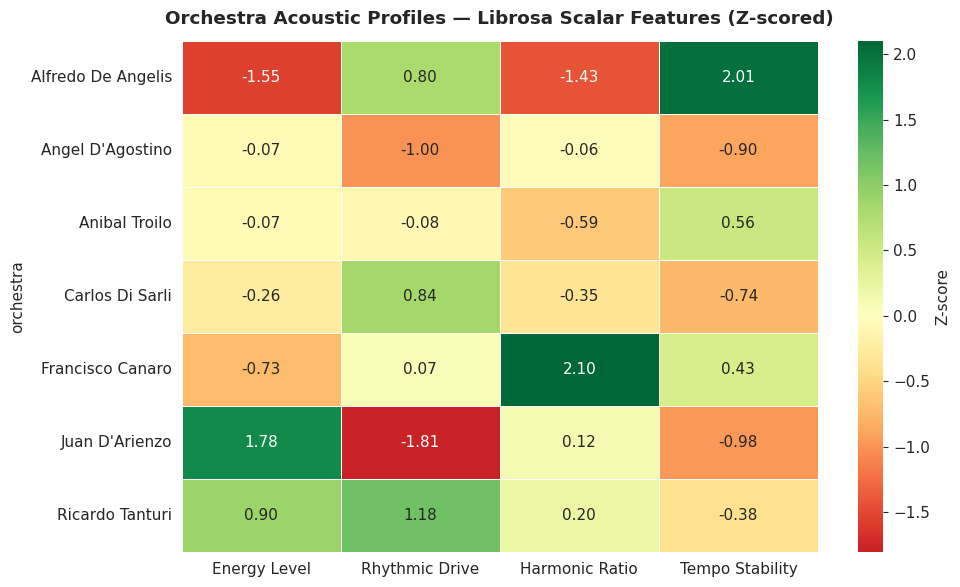

Within-orchestra std vs overall std:
Orchestra                        Avg within-std  (overall: 0.0366)
------------------------------------------------------------
Alfredo De Angelis                       0.0282  consistent
Anibal Troilo                            0.0288  consistent
Carlos Di Sarli                          0.0289  consistent
Ricardo Tanturi                          0.0301  consistent
Juan D'Arienzo                           0.0343  
Angel D'Agostino                         0.0359  
Francisco Canaro                         0.0421  


In [14]:
key_scalars = ['rms_mean', 'onset_strength_mean', 'harmonic_energy_ratio', 'tempogram_max_bin_strength']
orch_profile = df_orch.groupby('orchestra')[key_scalars].mean()

scaler = StandardScaler()
orch_norm = pd.DataFrame(
    scaler.fit_transform(orch_profile),
    index=orch_profile.index,
    columns=[READABLE.get(c, c) for c in orch_profile.columns]
)

fig, ax = plt.subplots(figsize=(10, max(6, len(valid_orchs) * 0.45)))
sns.heatmap(orch_norm, cmap='RdYlGn', center=0, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Z-score'})
ax.set_title('Orchestra Acoustic Profiles — Librosa Scalar Features (Z-scored)', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

within_var = df_orch.groupby('orchestra')[key_scalars].std().mean(axis=1)
across_var = df_orch[key_scalars].std().mean()

print('Within-orchestra std vs overall std:')
print(f'{"Orchestra":<30} {"Avg within-std":>16}  (overall: {across_var:.4f})')
print('-' * 60)
for orch in within_var.sort_values().index:
    flag = 'consistent' if within_var[orch] < across_var * 0.85 else ''
    print(f'{orch:<30} {within_var[orch]:>16.4f}  {flag}')

## 5. MFCC Vector Analysis — Dimensionality Reduction

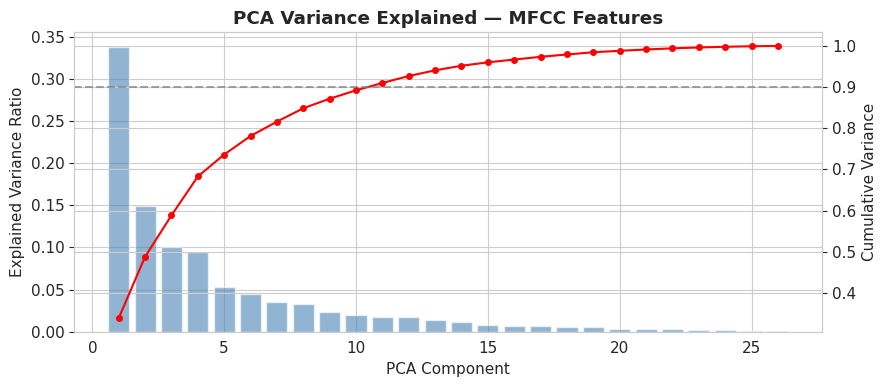

Components needed for 90% variance: 11


In [15]:
X_mfcc = merged[MFCC_COLS].values
X_mfcc_scaled = StandardScaler().fit_transform(X_mfcc)

pca = PCA()
pca.fit(X_mfcc_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, len(cumvar)+1), pca.explained_variance_ratio_, alpha=0.6, color='steelblue')
ax2 = ax.twinx()
ax2.plot(range(1, len(cumvar)+1), cumvar, 'r-o', markersize=4)
ax2.axhline(0.9, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('PCA Component')
ax.set_ylabel('Explained Variance Ratio')
ax2.set_ylabel('Cumulative Variance')
ax.set_title('PCA Variance Explained — MFCC Features', fontweight='bold')
plt.tight_layout()
plt.show()
n90 = np.searchsorted(cumvar, 0.90) + 1
print(f'Components needed for 90% variance: {n90}')

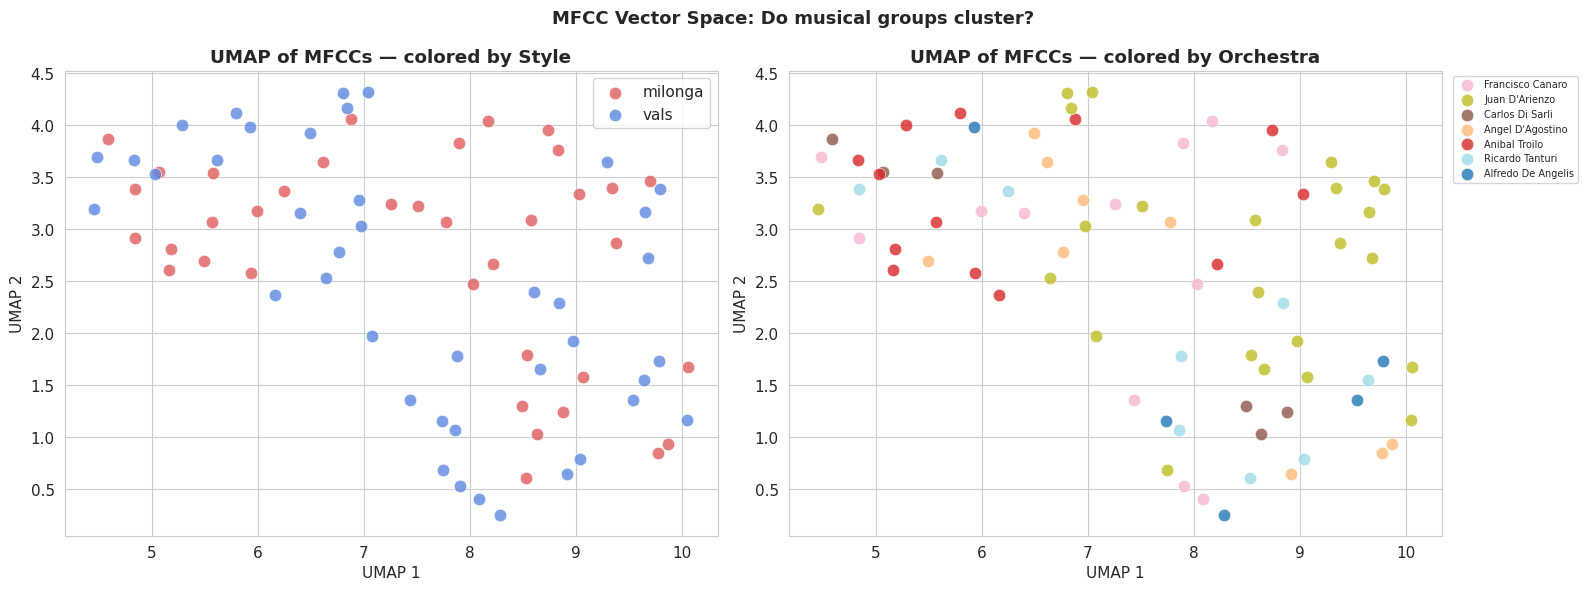

Silhouette — MFCC vs Style: 0.0087  (> 0.3 = meaningful, > 0.5 = strong)
Silhouette — MFCC vs Orchestra: -0.0463


In [16]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=min(10, len(X_mfcc)-1))
embedding = reducer.fit_transform(X_mfcc_scaled)

styles_arr = merged['style_from_file'].values
orchs = merged['orchestra'].fillna('Unknown').values
unique_orchs = [o for o in set(orchs) if list(orchs).count(o) >= 2]
cmap = cm.get_cmap('tab20', len(unique_orchs))
orch_color = {o: cmap(i) for i, o in enumerate(sorted(unique_orchs))}
colors_style = {'milonga': '#E05C5C', 'vals': '#5C87E0'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for s in ['milonga', 'vals']:
    mask = np.array(styles_arr) == s
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=colors_style[s], label=s, alpha=0.8, s=80, edgecolors='white', linewidth=0.5)
ax.set_title('UMAP of MFCCs — colored by Style', fontweight='bold')
ax.legend(); ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

ax = axes[1]
plotted = set()
for i, (x, y) in enumerate(embedding):
    o = orchs[i]
    color = orch_color.get(o, (0.7, 0.7, 0.7, 0.3))
    label = o if o not in plotted and o in orch_color else None
    ax.scatter(x, y, c=[color], alpha=0.8, s=80, label=label, edgecolors='white', linewidth=0.5)
    plotted.add(o)
ax.set_title('UMAP of MFCCs — colored by Orchestra', fontweight='bold')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

plt.suptitle('MFCC Vector Space: Do musical groups cluster?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

le_style = pd.factorize(merged['style_from_file'])[0]
sil_style = silhouette_score(X_mfcc_scaled, le_style)
print(f'Silhouette — MFCC vs Style: {sil_style:.4f}  (> 0.3 = meaningful, > 0.5 = strong)')

df_valid = merged[merged['orchestra'].isin(valid_orchs)].copy()
X_orch = StandardScaler().fit_transform(df_valid[MFCC_COLS].values)
le_orch = pd.factorize(df_valid['orchestra'])[0]
sil_orch = silhouette_score(X_orch, le_orch)
print(f'Silhouette — MFCC vs Orchestra: {sil_orch:.4f}')

## 6. Chroma Analysis

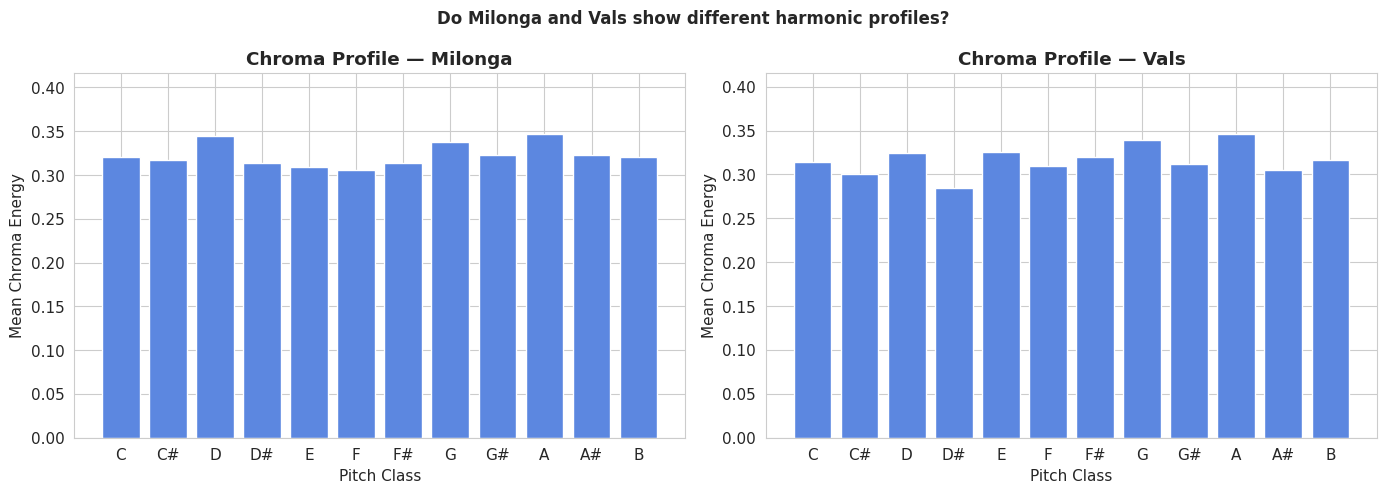

Median chroma spread — milonga: 0.0632
Median chroma spread — vals:    0.0605

If spread < 0.05, chroma features are unreliable (too flat) on this corpus.


In [17]:
chroma_mean_cols = [c for c in CHROMA_COLS if c.endswith('_mean')]
pitch_classes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, style in zip(axes, ['milonga', 'vals']):
    subset = merged[merged['style_from_file'] == style][chroma_mean_cols].mean()
    ax.bar(pitch_classes, subset.values, color='#5C87E0', edgecolor='white')
    ax.set_title(f'Chroma Profile — {style.capitalize()}', fontweight='bold')
    ax.set_xlabel('Pitch Class'); ax.set_ylabel('Mean Chroma Energy')
    ax.set_ylim(0, subset.max() * 1.2)
fig.suptitle('Do Milonga and Vals show different harmonic profiles?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

chroma_spread = merged[chroma_mean_cols].std(axis=1)
print(f'Median chroma spread — milonga: {chroma_spread[merged.style_from_file=="milonga"].median():.4f}')
print(f'Median chroma spread — vals:    {chroma_spread[merged.style_from_file=="vals"].median():.4f}')
print('\nIf spread < 0.05, chroma features are unreliable (too flat) on this corpus.')

## 7. Spectral Contrast Analysis

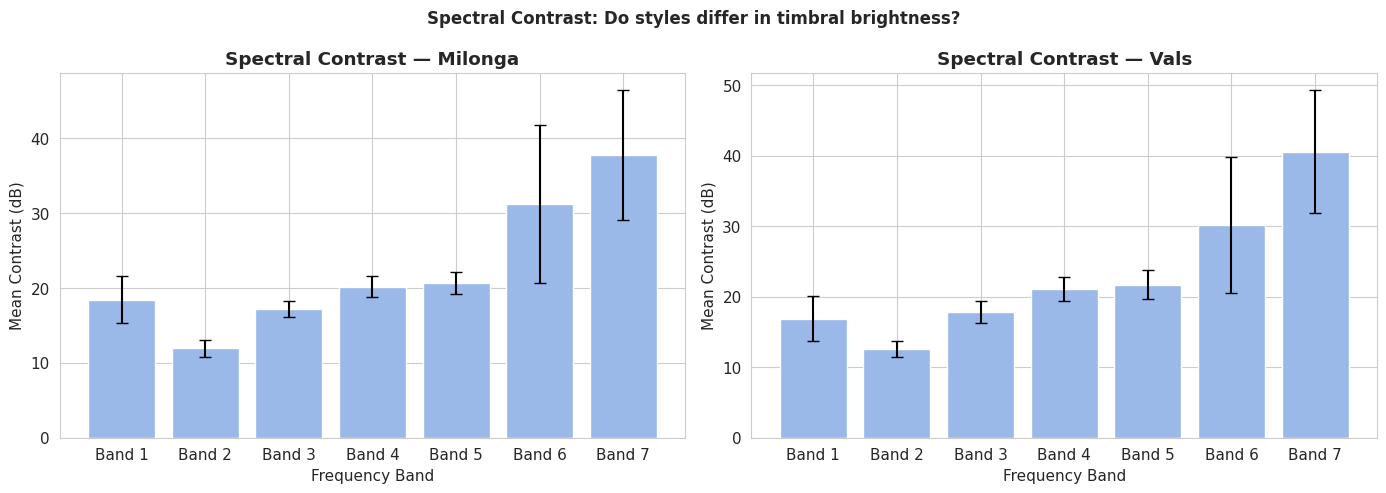

Band              Milonga mean    Vals mean    p-value   Significant?
----------------------------------------------------------------------
Band 1                  18.444       16.913     0.0358            YES
Band 2                  11.957       12.586     0.0183            YES
Band 3                  17.200       17.808     0.0548             NO
Band 4                  20.157       21.117     0.0084            YES
Band 5                  20.725       21.726     0.0169            YES
Band 6                  31.257       30.137     0.6265             NO
Band 7                  37.789       40.573     0.1620             NO


In [19]:
spectral_mean_cols = [c for c in SPECTRAL_COLS if c.endswith('_mean')]
band_labels = [f'Band {i+1}' for i in range(len(spectral_mean_cols))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, style in zip(axes, ['milonga', 'vals']):
    subset = merged[merged['style_from_file'] == style][spectral_mean_cols]
    ax.bar(band_labels, subset.mean().values, yerr=subset.std().values,
           capsize=4, color='#9AB8E8', edgecolor='white')
    ax.set_title(f'Spectral Contrast — {style.capitalize()}', fontweight='bold')
    ax.set_xlabel('Frequency Band'); ax.set_ylabel('Mean Contrast (dB)')
fig.suptitle('Spectral Contrast: Do styles differ in timbral brightness?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"{'Band':<15} {'Milonga mean':>14} {'Vals mean':>12} {'p-value':>10} {'Significant?':>14}")
print('-' * 70)
for col, band in zip(spectral_mean_cols, band_labels):
    m = merged[merged['style_from_file']=='milonga'][col].dropna()
    v = merged[merged['style_from_file']=='vals'][col].dropna()
    t, p = stats.ttest_ind(m, v)
    sig = 'YES' if p < 0.05 else 'NO'
    print(f"{band:<15} {m.mean():>14.3f} {v.mean():>12.3f} {p:>10.4f} {sig:>14}")

## 8. Combined Vector — UMAP with All Feature Groups

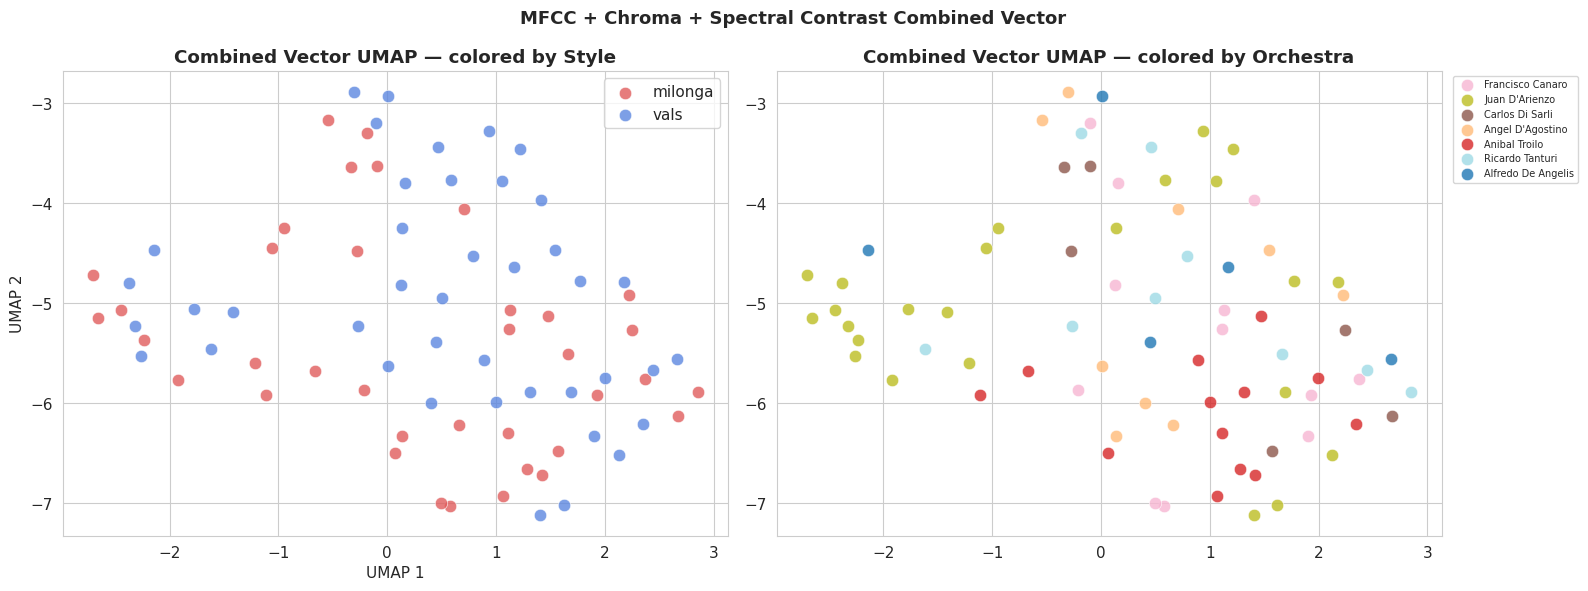

Silhouette — Combined vector vs Style: 0.0086
(Compare to MFCC-only: 0.0087)
If combined > MFCC-only: chroma/spectral are adding signal. If same/lower: they are not.


In [20]:
combined_cols = MFCC_COLS + CHROMA_COLS + SPECTRAL_COLS
X_combined = merged[combined_cols].values
X_combined_scaled = StandardScaler().fit_transform(X_combined)

reducer_combined = umap.UMAP(n_components=2, random_state=42, n_neighbors=min(10, len(X_combined)-1))
emb_combined = reducer_combined.fit_transform(X_combined_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
for s in ['milonga', 'vals']:
    mask = np.array(styles_arr) == s
    ax.scatter(emb_combined[mask, 0], emb_combined[mask, 1],
               c=colors_style[s], label=s, alpha=0.8, s=80, edgecolors='white', linewidth=0.5)
ax.set_title('Combined Vector UMAP — colored by Style', fontweight='bold')
ax.legend(); ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

ax = axes[1]
plotted = set()
for i, (x, y) in enumerate(emb_combined):
    o = orchs[i]
    color = orch_color.get(o, (0.7, 0.7, 0.7, 0.3))
    label = o if o not in plotted and o in orch_color else None
    ax.scatter(x, y, c=[color], alpha=0.8, s=80, label=label, edgecolors='white', linewidth=0.5)
    plotted.add(o)
ax.set_title('Combined Vector UMAP — colored by Orchestra', fontweight='bold')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.suptitle('MFCC + Chroma + Spectral Contrast Combined Vector', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

sil_combined = silhouette_score(X_combined_scaled, le_style)
print(f'Silhouette — Combined vector vs Style: {sil_combined:.4f}')
print(f'(Compare to MFCC-only: {sil_style:.4f})')
print('If combined > MFCC-only: chroma/spectral are adding signal. If same/lower: they are not.')

## 9. Feature Correlation — Redundancy Check (Librosa scalars)

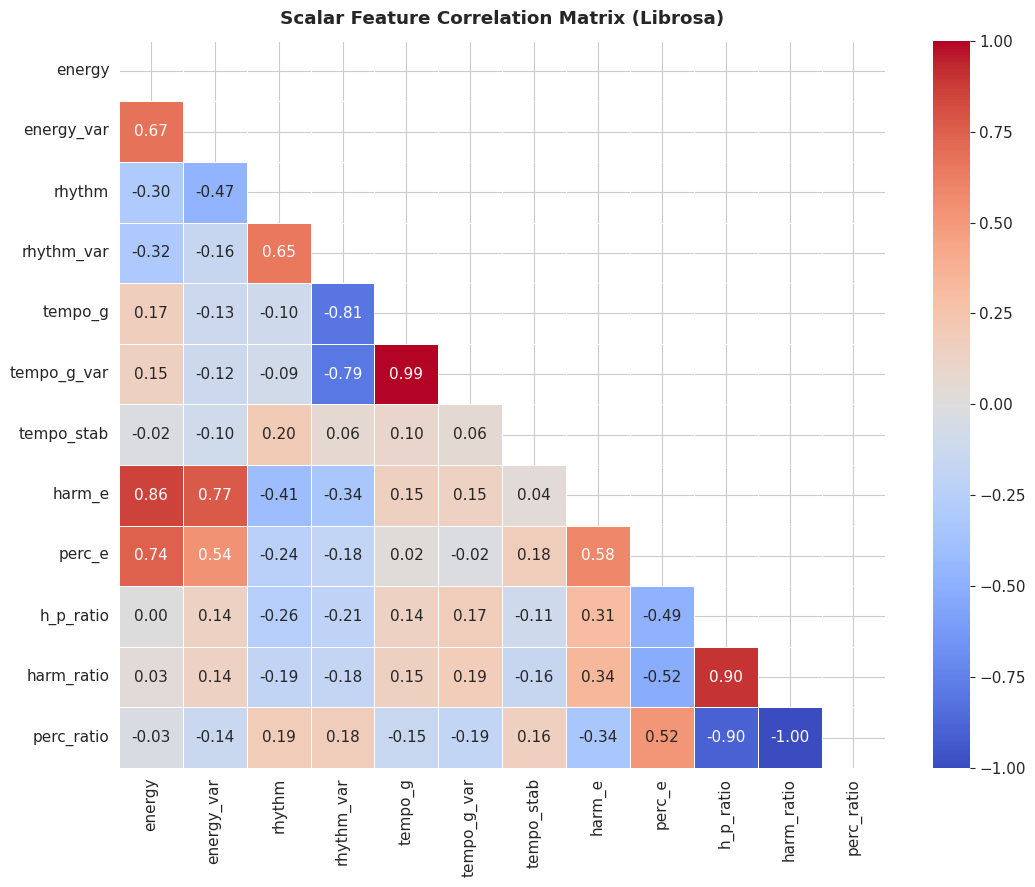

High correlations (|r| > 0.8) = redundant — keep only one from each pair:
  energy vs harm_e: r = 0.859
  rhythm_var vs tempo_g: r = -0.808
  tempo_g vs tempo_g_var: r = 0.995
  h_p_ratio vs harm_ratio: r = 0.905
  h_p_ratio vs perc_ratio: r = -0.905
  harm_ratio vs perc_ratio: r = -1.000


In [21]:
corr = merged[SCALAR_COLS].corr()
short = {
    'rms_mean': 'energy', 'rms_std': 'energy_var',
    'onset_strength_mean': 'rhythm', 'onset_strength_std': 'rhythm_var',
    'tempogram_global_mean': 'tempo_g', 'tempogram_global_std': 'tempo_g_var',
    'tempogram_max_bin_strength': 'tempo_stab',
    'harmonic_energy': 'harm_e', 'percussive_energy': 'perc_e',
    'harmonic_to_percussive_ratio': 'h_p_ratio',
    'harmonic_energy_ratio': 'harm_ratio', 'percussive_energy_ratio': 'perc_ratio',
}
corr.index = [short.get(c, c) for c in corr.index]
corr.columns = [short.get(c, c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Scalar Feature Correlation Matrix (Librosa)', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print('High correlations (|r| > 0.8) = redundant — keep only one from each pair:')
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            print(f'  {corr.columns[i]} vs {corr.columns[j]}: r = {r:.3f}')

---
# Essentia vs Librosa Redundancy

## 10. Are Librosa Scalar Features Redundant Given Essentia?

**Context:** Our real scoring objective is to rank combos against user prompts like:
- *"smooth warm milonga"* vs *"very rhythmic aggressive milonga"*
- *"sad vals"* vs *"happy vals"*
- *"warm smooth"* (no style specified)

Style is already known from the catalog. Features are needed to discriminate **within** a style by mood/energy character.

**Question:** Do librosa scalars (harmonic_ratio, rms_mean, onset_strength) add anything on top of what essentia already gives us (mood_relaxed, mood_sad, danceability, average_loudness)?

We test this by computing pairwise Pearson correlations between the "equivalent" feature pairs.

In [24]:
# Correlate librosa scalars against their essentia equivalents
# High r = librosa is measuring the same thing essentia already captures
# Low r = librosa is measuring something different (potentially complementary)

pairs = [
    ('harmonic_energy_ratio',    'mood_relaxed',     'Harmonic Ratio vs Relaxed Mood'),
    ('harmonic_energy_ratio',    'mood_sad',         'Harmonic Ratio vs Sad Mood'),
    ('harmonic_energy_ratio',    'mood_happy',       'Harmonic Ratio vs Happy Mood'),
    ('harmonic_to_percussive_ratio', 'mood_relaxed', 'H/P Ratio vs Relaxed Mood'),
    ('rms_mean',                 'average_loudness', 'Energy (rms) vs Avg Loudness'),
    ('onset_strength_mean',      'danceability',     'Onset Strength vs Danceability'),
    ('onset_strength_mean',      'onset_rate',       'Onset Strength vs Onset Rate'),
    ('tempogram_global_mean',    'bpm',              'Tempo (global mean) vs BPM'),
]

lib_cols  = [p[0] for p in pairs]
ess_cols  = [p[1] for p in pairs]
labels    = [p[2] for p in pairs]

rs, ps = [], []
print(f"{'Pair':<45} {'r':>8} {'p-value':>10} {'Interpretation':>25}")
print('-' * 95)
for lc, ec, lab in pairs:
    r, p = stats.pearsonr(both[lc], both[ec])
    rs.append(r); ps.append(p)
    if abs(r) > 0.7:
        interp = 'REDUNDANT (same info)'
    elif abs(r) > 0.4:
        interp = 'Partial overlap'
    elif p < 0.05:
        interp = 'Weak but real signal'
    else:
        interp = 'No meaningful corr'
    print(f"{lab:<45} {r:>8.3f} {p:>10.4f} {interp:>25}")

Pair                                                 r    p-value            Interpretation
-----------------------------------------------------------------------------------------------
Harmonic Ratio vs Relaxed Mood                   0.321     0.0042      Weak but real signal
Harmonic Ratio vs Sad Mood                       0.254     0.0246      Weak but real signal
Harmonic Ratio vs Happy Mood                    -0.143     0.2104        No meaningful corr
H/P Ratio vs Relaxed Mood                        0.331     0.0031      Weak but real signal
Energy (rms) vs Avg Loudness                     0.286     0.0110      Weak but real signal
Onset Strength vs Danceability                   0.298     0.0081      Weak but real signal
Onset Strength vs Onset Rate                     0.233     0.0402      Weak but real signal
Tempo (global mean) vs BPM                      -0.022     0.8458        No meaningful corr


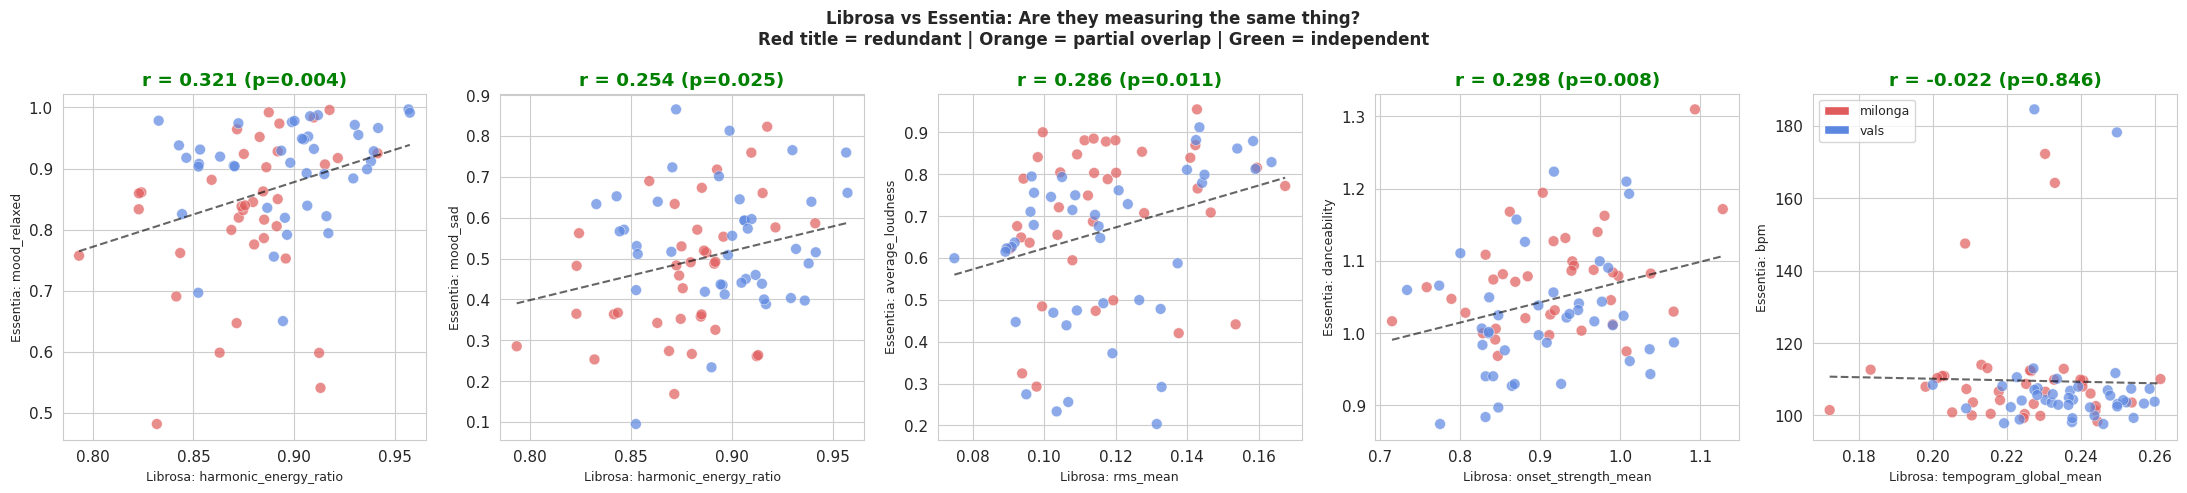


KEY FINDING: If r is high (red), the librosa feature adds no new information.
If r is low (green), librosa is capturing something essentia misses.


In [25]:
# Visualise the most important pairs as scatter plots
key_pairs = [
    ('harmonic_energy_ratio', 'mood_relaxed'),
    ('harmonic_energy_ratio', 'mood_sad'),
    ('rms_mean',              'average_loudness'),
    ('onset_strength_mean',   'danceability'),
    ('tempogram_global_mean', 'bpm'),
]

fig, axes = plt.subplots(1, len(key_pairs), figsize=(22, 5))
for ax, (lc, ec) in zip(axes, key_pairs):
    x = both[lc]; y = both[ec]
    r, p = stats.pearsonr(x, y)
    colors = [colors_style[s] for s in both['style_from_file']]
    ax.scatter(x, y, c=colors, alpha=0.7, s=60, edgecolors='white', linewidth=0.4)
    # Trend line
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m*xline + b, 'k--', linewidth=1.5, alpha=0.6)
    ax.set_xlabel(f'Librosa: {lc}', fontsize=9)
    ax.set_ylabel(f'Essentia: {ec}', fontsize=9)
    ax.set_title(f'r = {r:.3f} (p={p:.3f})', fontweight='bold',
                 color='red' if abs(r) > 0.7 else ('orange' if abs(r) > 0.4 else 'green'))

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E05C5C', label='milonga'),
                   Patch(facecolor='#5C87E0', label='vals')]
axes[-1].legend(handles=legend_elements, fontsize=9)

fig.suptitle('Librosa vs Essentia: Are they measuring the same thing?\n'
             'Red title = redundant | Orange = partial overlap | Green = independent',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('KEY FINDING: If r is high (red), the librosa feature adds no new information.')
print('If r is low (green), librosa is capturing something essentia misses.')

## 11. Do Essentia Mood Features Actually Separate Orchestras?

**This is the critical test for our pipeline.** Even if essentia mood features are good *in principle*, they need to:
1. Produce **consistent scores within an orchestra** (low within-orchestra variance)
2. Produce **different scores across orchestras** (high between-orchestra variance)
3. Order orchestras in a way that **matches musical ground truth**

Ground truth expectation for milonga:
- Di Sarli → smooth, warm, high `mood_relaxed`
- D'Arienzo → rhythmic, driving, lower `mood_relaxed`, lower `mood_sad`
- Troilo → balanced, expressive
- Canaro → melodic, accessible

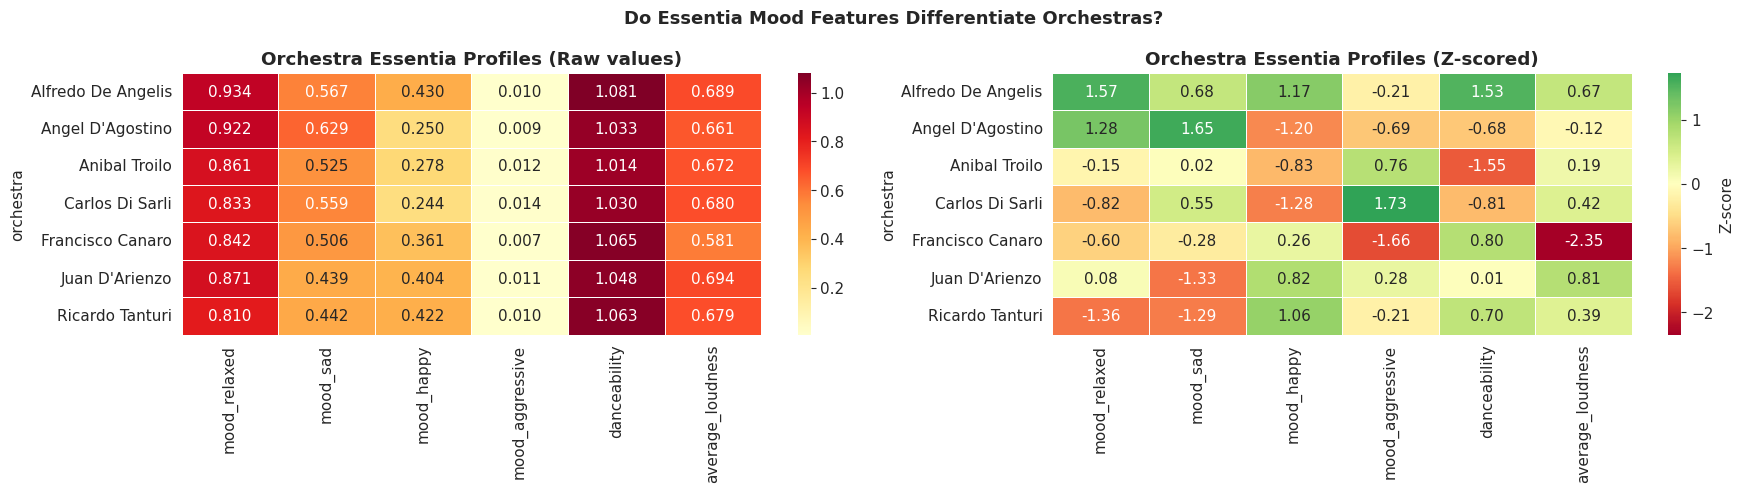

Raw values:
                    mood_relaxed  mood_sad  mood_happy  mood_aggressive  danceability  average_loudness
orchestra                                                                                              
Alfredo De Angelis         0.934     0.567       0.430            0.010         1.081             0.689
Angel D'Agostino           0.922     0.629       0.250            0.009         1.033             0.661
Anibal Troilo              0.861     0.525       0.278            0.012         1.014             0.672
Carlos Di Sarli            0.833     0.559       0.244            0.014         1.030             0.680
Francisco Canaro           0.842     0.506       0.361            0.007         1.065             0.581
Juan D'Arienzo             0.871     0.439       0.404            0.011         1.048             0.694
Ricardo Tanturi            0.810     0.442       0.422            0.010         1.063             0.679

Musical ground truth check:
  Di Sarli should be: h

In [26]:
# Orchestra profiles using essentia mood features
ess_orch = ess_merged[ess_merged['orchestra'].isin(valid_orchs)].copy()

mood_cols = ['mood_relaxed', 'mood_sad', 'mood_happy', 'mood_aggressive', 'danceability', 'average_loudness']
orch_ess_profile = ess_orch.groupby('orchestra')[mood_cols].mean().round(3)

# Normalize for heatmap
orch_ess_norm = pd.DataFrame(
    StandardScaler().fit_transform(orch_ess_profile),
    index=orch_ess_profile.index,
    columns=orch_ess_profile.columns
)

fig, axes = plt.subplots(1, 2, figsize=(18, max(5, len(valid_orchs) * 0.6)))

# Raw values
sns.heatmap(orch_ess_profile, cmap='YlOrRd', annot=True, fmt='.3f',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Orchestra Essentia Profiles (Raw values)', fontweight='bold')

# Z-scored
sns.heatmap(orch_ess_norm, cmap='RdYlGn', center=0, annot=True, fmt='.2f',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Z-score'})
axes[1].set_title('Orchestra Essentia Profiles (Z-scored)', fontweight='bold')

plt.suptitle('Do Essentia Mood Features Differentiate Orchestras?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Raw values:')
print(orch_ess_profile.to_string())
print()
print('Musical ground truth check:')
print('  Di Sarli should be: high mood_relaxed, moderate mood_sad')
print("  D'Arienzo should be: lower mood_relaxed, higher danceability")
print('  Canaro should be: highest mood_relaxed (melodic, smooth)')

In [27]:
# Within-orchestra consistency for essentia mood features
within_ess = ess_orch.groupby('orchestra')[mood_cols].std().mean(axis=1)
overall_ess_std = ess_orch[mood_cols].std().mean()

print(f'Within-orchestra std vs overall std (essentia mood features):')
print(f'Overall std across all tracks: {overall_ess_std:.4f}')
print()
print(f'{"Orchestra":<30} {"Avg within-std":>16} {"% of overall":>14} {"Consistent?":>14}')
print('-' * 75)
for orch in within_ess.sort_values().index:
    pct = within_ess[orch] / overall_ess_std * 100
    flag = '✓ YES' if within_ess[orch] < overall_ess_std * 0.85 else '✗ noisy'
    print(f'{orch:<30} {within_ess[orch]:>16.4f} {pct:>13.1f}% {flag:>14}')

print()
print('Interpretation: if within-std << overall-std, the orchestra has a consistent mood profile.')
print('This means the features are stable enough to use for combo scoring.')

Within-orchestra std vs overall std (essentia mood features):
Overall std across all tracks: 0.1145

Orchestra                        Avg within-std   % of overall    Consistent?
---------------------------------------------------------------------------
Alfredo De Angelis                       0.0551          48.1%          ✓ YES
Carlos Di Sarli                          0.0833          72.8%          ✓ YES
Angel D'Agostino                         0.0984          85.9%        ✗ noisy
Juan D'Arienzo                           0.1017          88.8%        ✗ noisy
Anibal Troilo                            0.1084          94.7%        ✗ noisy
Ricardo Tanturi                          0.1327         115.9%        ✗ noisy
Francisco Canaro                         0.1395         121.9%        ✗ noisy

Interpretation: if within-std << overall-std, the orchestra has a consistent mood profile.
This means the features are stable enough to use for combo scoring.


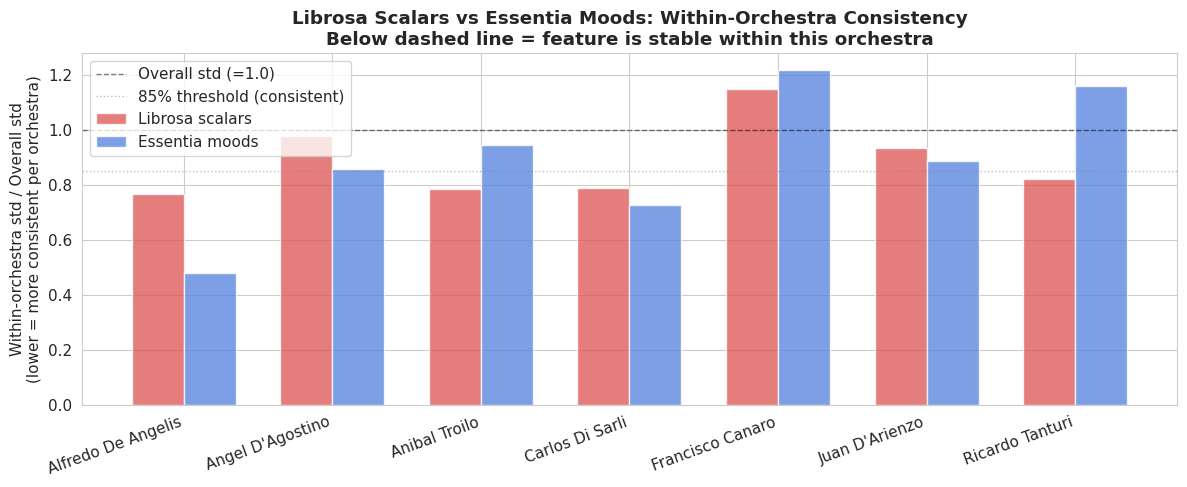

Winner per orchestra (lower ratio = more consistent = more trustworthy for scoring):
  Alfredo De Angelis             Librosa=0.769  Essentia=0.481  → Essentia
  Angel D'Agostino               Librosa=0.980  Essentia=0.859  → Essentia
  Anibal Troilo                  Librosa=0.787  Essentia=0.947  → Librosa
  Carlos Di Sarli                Librosa=0.790  Essentia=0.728  → Essentia
  Francisco Canaro               Librosa=1.148  Essentia=1.219  → Librosa
  Juan D'Arienzo                 Librosa=0.936  Essentia=0.888  → Essentia
  Ricardo Tanturi                Librosa=0.821  Essentia=1.159  → Librosa


In [28]:
# Compare within-orchestra consistency: librosa scalars vs essentia moods
# Which one is more consistent per orchestra — and therefore more trustworthy for scoring?

lib_within = df_orch.groupby('orchestra')[key_scalars].std().mean(axis=1)
lib_overall = df_orch[key_scalars].std().mean()
lib_ratio = lib_within / lib_overall

ess_within = ess_orch.groupby('orchestra')[mood_cols].std().mean(axis=1)
ess_overall = ess_orch[mood_cols].std().mean()
ess_ratio = ess_within / ess_overall

orchs_common = sorted(set(lib_within.index) & set(ess_within.index))

x = np.arange(len(orchs_common))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, [lib_ratio[o] for o in orchs_common], width,
               label='Librosa scalars', color='#E05C5C', alpha=0.8)
bars2 = ax.bar(x + width/2, [ess_ratio[o] for o in orchs_common], width,
               label='Essentia moods', color='#5C87E0', alpha=0.8)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Overall std (=1.0)')
ax.axhline(0.85, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='85% threshold (consistent)')
ax.set_xticks(x)
ax.set_xticklabels(orchs_common, rotation=20, ha='right')
ax.set_ylabel('Within-orchestra std / Overall std\n(lower = more consistent per orchestra)')
ax.set_title('Librosa Scalars vs Essentia Moods: Within-Orchestra Consistency\n'
             'Below dashed line = feature is stable within this orchestra', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Winner per orchestra (lower ratio = more consistent = more trustworthy for scoring):')
for o in orchs_common:
    winner = 'Librosa' if lib_ratio[o] < ess_ratio[o] else 'Essentia'
    print(f'  {o:<30} Librosa={lib_ratio[o]:.3f}  Essentia={ess_ratio[o]:.3f}  → {winner}')

## 12. Essentia Mood Features: Style Separation Test

Re-run the style separation t-test on essentia features, in the same format as Section 3, for direct comparison.

In [31]:
ess_mil = ess_merged[ess_merged['style_from_file'] == 'milonga']
ess_val = ess_merged[ess_merged['style_from_file'] == 'vals']

all_ess_cols = ESSENTIA_MOOD + ESSENTIA_CORE

print(f"{'Essentia Feature':<45} {'Milonga mean':>13} {'Vals mean':>11} {'p-value':>10} {'Separates?':>12}")
print('-' * 98)
for col in all_ess_cols:
    t, p = stats.ttest_ind(ess_mil[col].dropna(), ess_val[col].dropna())
    sep = 'YES' if p < 0.05 else 'NO'
    print(f"{col:<45} {ess_mil[col].mean():>13.4f} {ess_val[col].mean():>11.4f} {p:>10.4f} {sep:>12}")

Essentia Feature                               Milonga mean   Vals mean    p-value   Separates?
--------------------------------------------------------------------------------------------------
mood_happy                                           0.3355      0.3634     0.3931           NO
mood_sad                                             0.4675      0.5359     0.0556           NO
mood_relaxed                                         0.8243      0.9010     0.0017          YES
mood_aggressive                                      0.0109      0.0101     0.5747           NO
mood_party                                           0.1049      0.0677     0.0138          YES
mood_acoustic                                        0.6363      0.6501     0.6771           NO
bpm                                                110.8994    108.2367     0.4843           NO
onset_rate                                           4.0000      3.9035     0.3551           NO
danceability                         

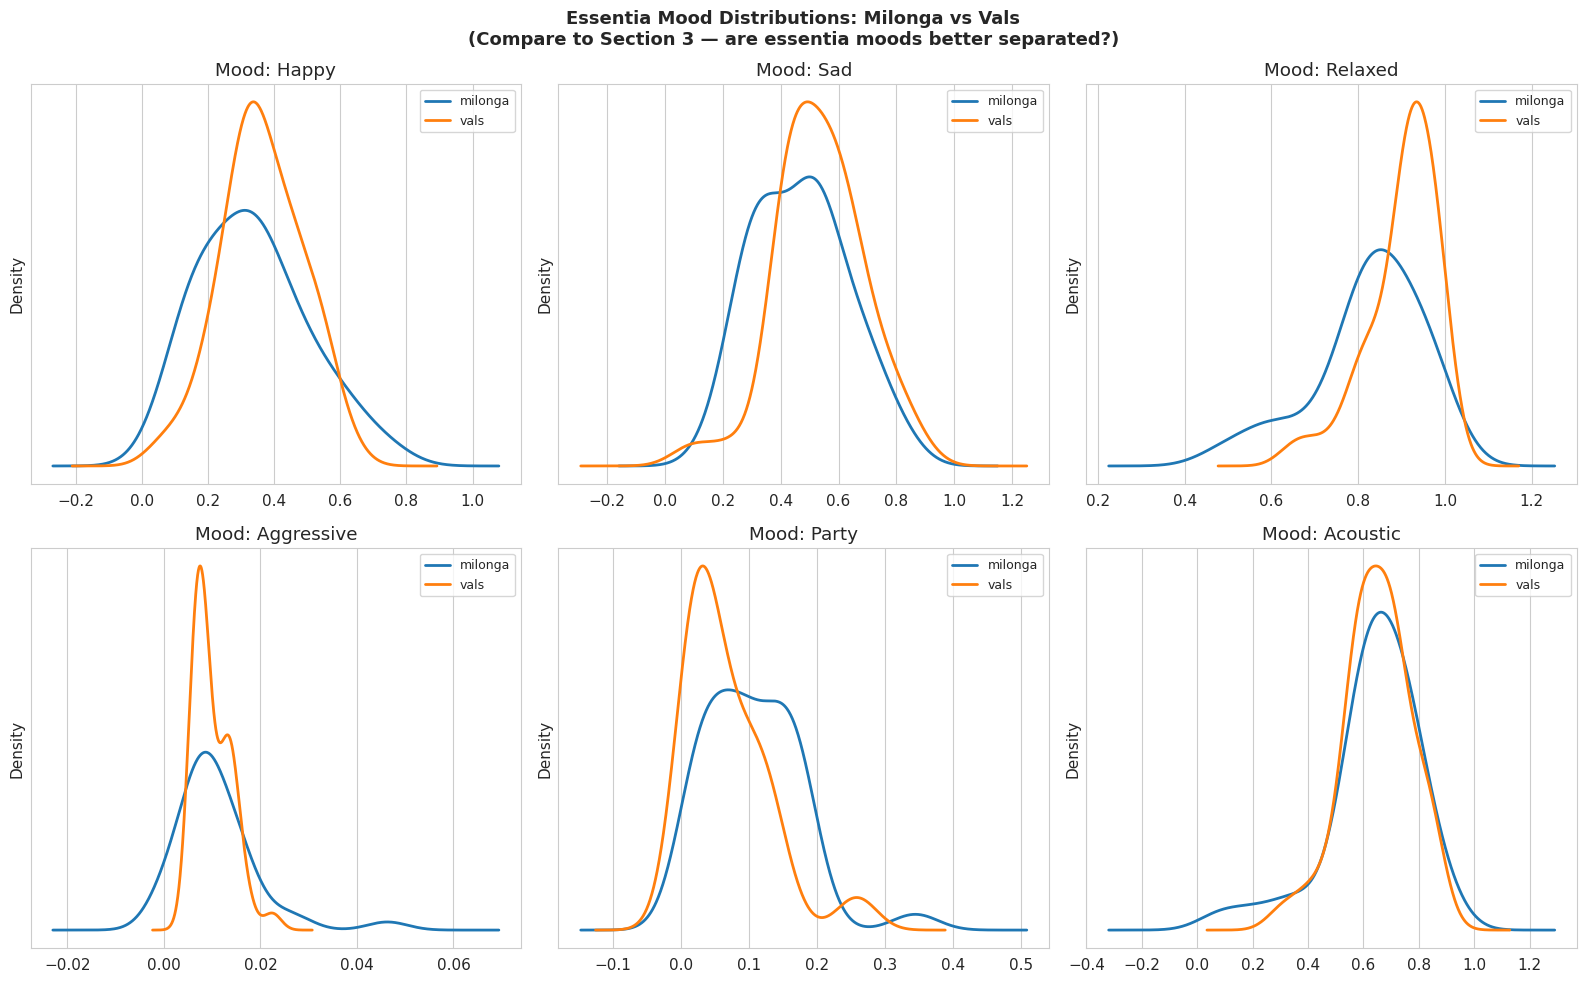

In [32]:
# Side-by-side KDE: essentia moods milonga vs vals
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(ESSENTIA_MOOD):
    ax = axes[i]
    for style, grp in ess_merged.groupby('style_from_file'):
        grp[col].plot.kde(ax=ax, label=style, linewidth=2)
    ax.set_title(col.replace('mood_', 'Mood: ').title())
    ax.legend(fontsize=9)
    ax.set_yticks([])

fig.suptitle('Essentia Mood Distributions: Milonga vs Vals\n'
             '(Compare to Section 3 — are essentia moods better separated?)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Key Issue: Is `mood_aggressive` Usable?

For prompts like *"rhythmic aggressive milonga"*, we would need `mood_aggressive` to have enough range to be useful. Check its distribution.

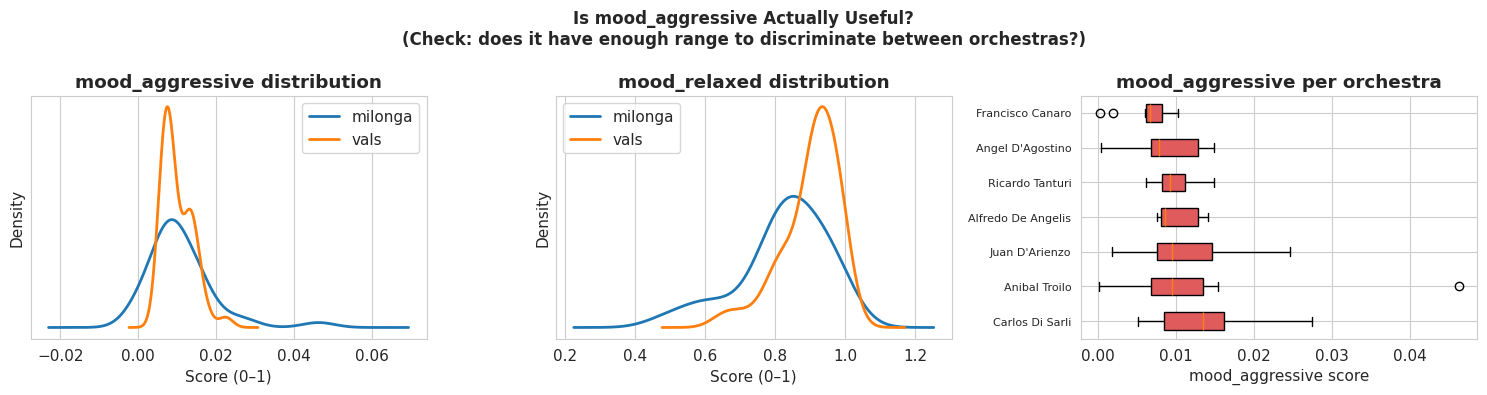

mood_aggressive descriptive stats:
count    78.0000
mean      0.0105
std       0.0065
min       0.0001
25%       0.0068
50%       0.0086
75%       0.0133
max       0.0463
Name: mood_aggressive, dtype: float64

Range: 0.0462
CV (std/mean): 0.619

If CV < 0.5 and range < 0.1: mood_aggressive is compressed — model is not discriminating well.
Compare to mood_relaxed CV: 0.128


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of mood_aggressive
ax = axes[0]
for style, grp in ess_merged.groupby('style_from_file'):
    grp['mood_aggressive'].plot.kde(ax=ax, label=style, linewidth=2)
ax.set_title('mood_aggressive distribution', fontweight='bold')
ax.legend(); ax.set_yticks([])
ax.set_xlabel('Score (0–1)')

# mood_relaxed — this is the one with most range
ax = axes[1]
for style, grp in ess_merged.groupby('style_from_file'):
    grp['mood_relaxed'].plot.kde(ax=ax, label=style, linewidth=2)
ax.set_title('mood_relaxed distribution', fontweight='bold')
ax.legend(); ax.set_yticks([])
ax.set_xlabel('Score (0–1)')

# Box plot comparing mood_aggressive per orchestra
ax = axes[2]
ess_orch_sub = ess_orch.copy()
orch_order = ess_orch_sub.groupby('orchestra')['mood_aggressive'].mean().sort_values(ascending=False).index.tolist()
data = [ess_orch_sub[ess_orch_sub['orchestra']==o]['mood_aggressive'].values for o in orch_order]
bp = ax.boxplot(data, labels=orch_order, patch_artist=True, vert=False)
for patch in bp['boxes']:
    patch.set_facecolor('#E05C5C')
ax.set_title('mood_aggressive per orchestra', fontweight='bold')
ax.set_xlabel('mood_aggressive score')
plt.setp(ax.get_yticklabels(), fontsize=8)

fig.suptitle('Is mood_aggressive Actually Useful?\n'
             '(Check: does it have enough range to discriminate between orchestras?)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('mood_aggressive descriptive stats:')
print(ess_merged['mood_aggressive'].describe().round(4))
print()
print(f'Range: {ess_merged["mood_aggressive"].max() - ess_merged["mood_aggressive"].min():.4f}')
print(f'CV (std/mean): {ess_merged["mood_aggressive"].std() / ess_merged["mood_aggressive"].mean():.3f}')
print()
print('If CV < 0.5 and range < 0.1: mood_aggressive is compressed — model is not discriminating well.')
print('Compare to mood_relaxed CV:', round(ess_merged['mood_relaxed'].std() / ess_merged['mood_relaxed'].mean(), 3))

## Summary of Findings & Conclusions

### Librosa Scalar Features
The t-tests in Section 3 show that energy level (rms_mean, p=0.92) and rhythmic drive (onset_strength_mean, p=0.51) fail completely to separate milonga from vals, suggesting they are dominated by recording-era mastering rather than musical character. Harmonic ratio and H/P ratio do separate styles (p < 0.01),but Section 10 shows these correlate only weakly with essentia's mood_relaxed (r = 0.32) and mood_sad (r = 0.25).

This means they are not fully redundant, but essentia captures most of the same signal through better-calibrated pretrained classifiers. The most damning result is tempogram_global_mean vs essentia BPM: r = −0.02, meaning librosa's tempo estimate is essentially uncorrelated with essentia's beat tracker on this corpus.

**=> drop all librosa scalar features.**


---
### MFCC, Chroma, and Spectral Contrast Vectors
MFCC clustering is essentially random — silhouette score of 0.009 for style separation and −0.046 for orchestra separation, both far below the 0.3 threshold for meaningful clusters. The combined MFCC+chroma+spectral vector (silhouette 0.0086) performs identically to MFCCs alone (0.0087), confirming chroma and spectral contrast add nothing on top. The chroma profiles are nearly flat across all 12 pitch classes for both styles, indicating the feature is too noisy on these old mono recordings to carry key information reliably.

**=> drop all three vector feature groups.**

---

### Extra observations on essentia Mood Features
The essentia pretrained classifiers perform meaningfully better. mood_relaxed separates milonga from vals at p=0.0017, and danceability at p=0.004. The orchestra heatmap in Section 11 shows interpretable profiles that partially match musical ground truth: Alfredo De Angelis and Angel D'Agostino score highest on mood_relaxed, while Juan D'Arienzo and Ricardo Tanturi score lower on mood_sad and higher on mood_happy, which is consistent with their brighter, more rhythmically driving character. Within-orchestra consistency analysis shows Alfredo De Angelis (48.1% of overall std) and Carlos Di Sarli (72.8%) have stable profiles suitable for scoring, though Troilo, Tanturi, and Canaro are noisier.

### mood_aggressive Is Not Usable
Despite having a high CV (0.619), mood_aggressive has an extremely compressed range — mean 0.010, max 0.046, all tracks essentially near zero. The pretrained model was not calibrated for tango and cannot distinguish aggressive from non-aggressive in this corpus. For user prompts involving "rhythmic" or "aggressive" or similar word choices, danceability and onset_rate are better proxies.